# Gradient Descent

## 1. Introduction
Gradient Descent is an optimization algorithm used to minimize a cost (loss) function in machine learning models. It iteratively adjusts model parameters (weights) to find the optimal values that reduce prediction error.

## 2. Intuition
- Imagine you are standing on a hill and want to reach the lowest point.
- You take steps in the direction of the steepest downward slope.
- Gradient Descent follows this same idea mathematically.

## 3. Cost Function
A cost function measures how wrong the model is.

Example (Mean Squared Error for Linear Regression):
\[
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x_i) - y_i)^2
\]

Where:
- \( m \) = number of training examples  
- \( h_\theta(x) \) = predicted value  
- \( y \) = actual value  

## 4. Gradient Descent Formula

\[
\theta := \theta - \alpha \cdot \frac{\partial J(\theta)}{\partial \theta}
\]

Where:
- \( \theta \) = model parameters  
- \( \alpha \) = learning rate  
- \( \frac{\partial J}{\partial \theta} \) = gradient (slope of cost function)


In [2]:
from sklearn.datasets import make_regression
import numpy as np

In [3]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

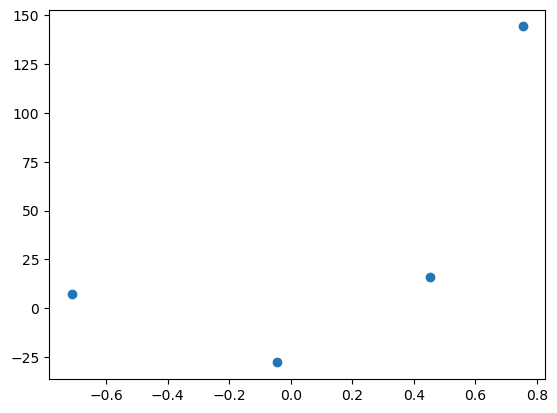

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [5]:
# Lets apply OLS( Ordinary least squares ) 
from sklearn.linear_model import LinearRegression

In [6]:
reg = LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
reg.coef_

array([78.35063668])

In [8]:
reg.intercept_

np.float64(26.15963284313262)

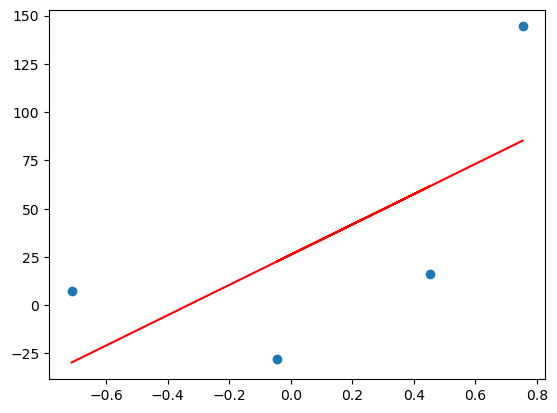

In [9]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [10]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 100).reshape(4)

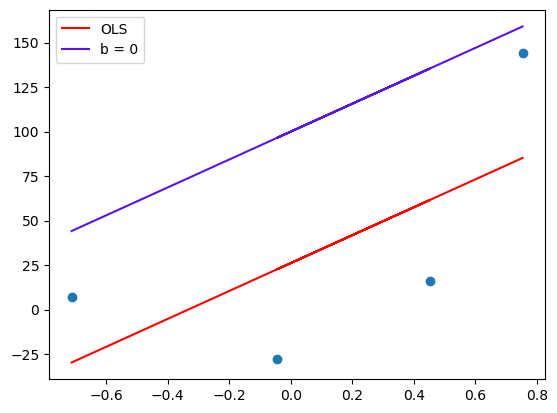

In [11]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color="#5a15e2",label='b = 0')
plt.legend()
plt.show()




In [12]:
m = 78.35
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(590.7223659179078)

In [13]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(59.072236591790784)

In [14]:
# Calculating the new intercept
b = b - step_size
b
   

np.float64(40.927763408209216)

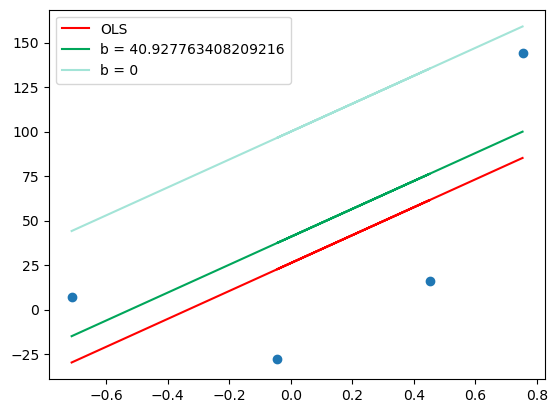

In [15]:

y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [16]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(118.14447318358157)

In [17]:
step_size = loss_slope*lr
step_size

np.float64(11.814447318358157)

In [18]:
b = b - step_size
b  

np.float64(29.11331608985106)

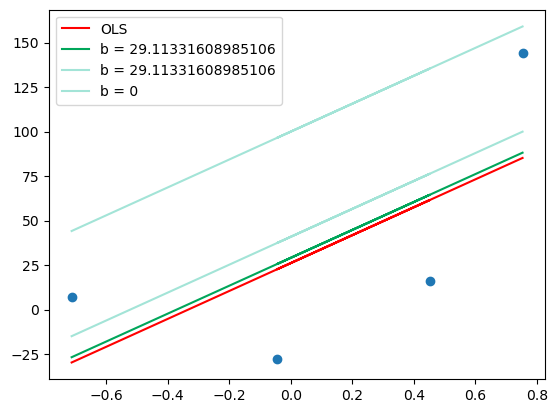

In [19]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [20]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(23.62889463671634)

In [21]:
step_size = loss_slope*lr
step_size

np.float64(2.362889463671634)

In [22]:
b = b - step_size
b

np.float64(26.750426626179426)

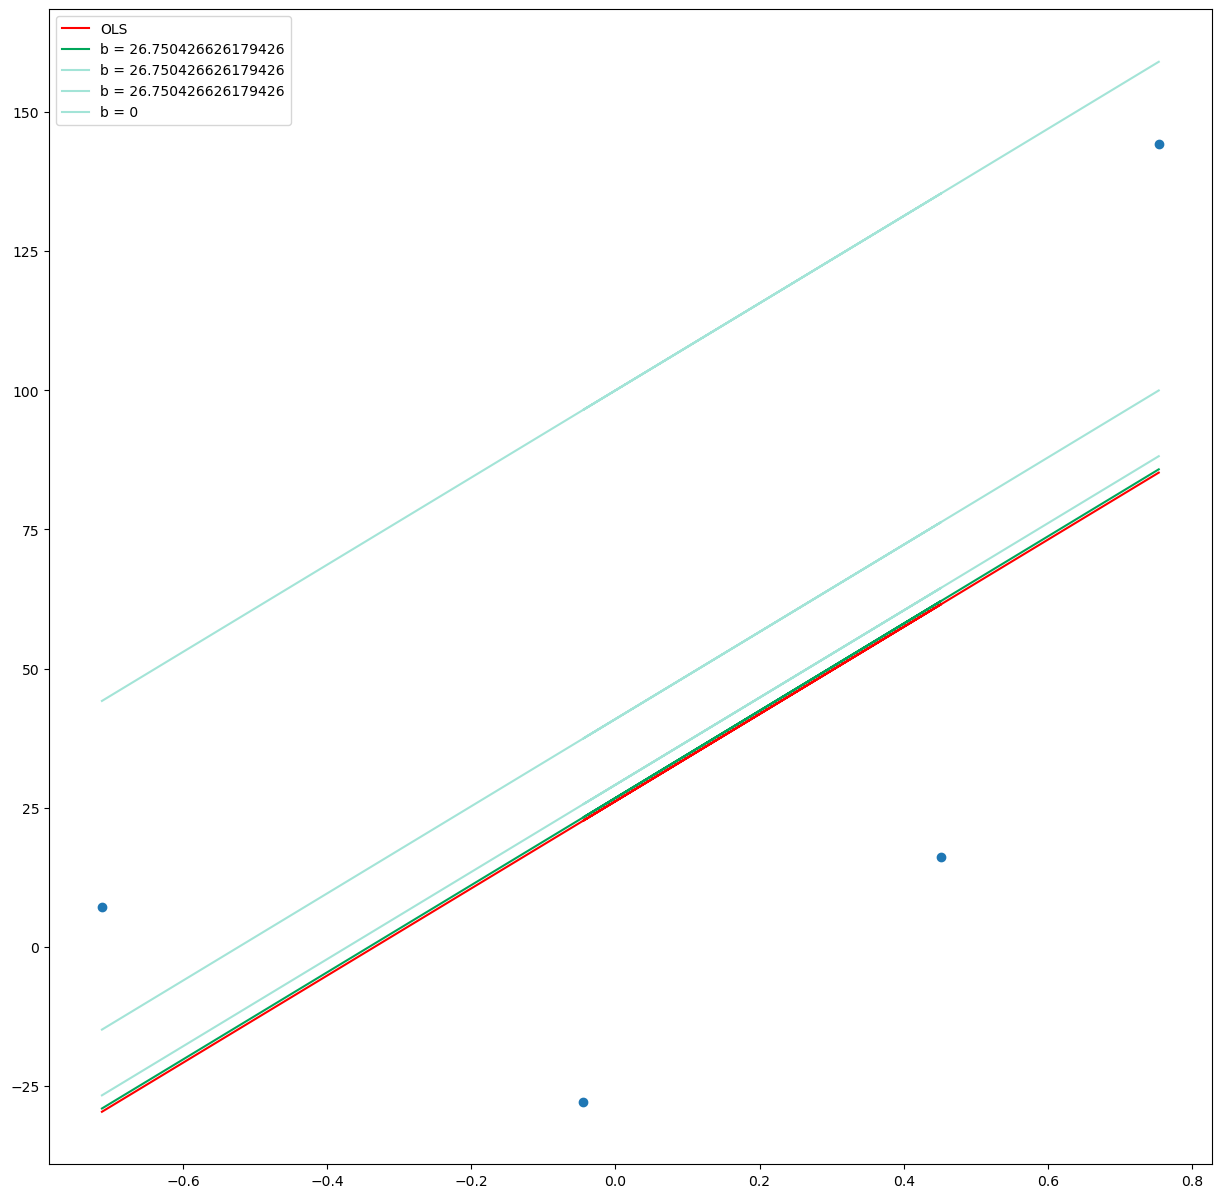

In [23]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()
     